# PyTorch CNN

https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

We will do the following steps in order:

1.Load and normalize the CIFAR10 training and test datasets using torchvision

2.Define a Convolutional Neural Network

3.Define a loss function

4.Train the network on the training data

5.Test the network on the test data

In [96]:
import torch
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from torch.utils.data import dataloader

In [97]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 4
NUM_EPOCHES = 10

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [98]:
torch.version
torch.version.cuda
torch.cuda.is_available()

True

In [99]:
transform = transforms.Compose(
            [transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


trainset = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


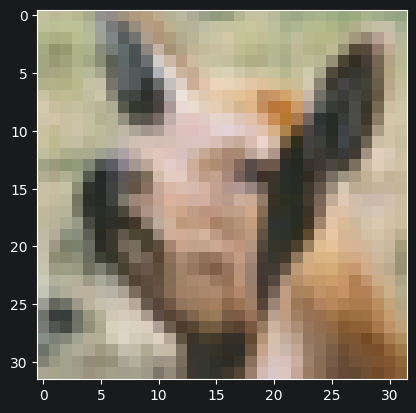

In [100]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
img = images[0] * 0.5 + 0.5
plt.imshow(img.permute(1, 2, 0))
#imshow(torchvision.utils.make_grid(images))

# Define a Convolutional Neural Network

In [111]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = torch.flatten(x, 1) # flatten all dimensions except batch
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

net = Net()

# Define a Loss function and optimizer
Let’s use a Classification Cross-Entropy loss and SGD with momentum.

In [102]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=LEARING_RATE, momentum=MOMENTUM)

In [116]:
def plot_metric(acc_metric_train,loss_metric_train):#,acc_metric_test,loss_metric_test

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    #loss metric plots
    axes[0].plot(loss_metric_train, label='Training')
#   axes[0].plt.plot(loss_metric_test, label='Testing')

    axes[0].set_title("Loss")
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    axes[0].legend()
    axes[0].grid(True)

    #Accuracy metric plotsµ

    axes[1].plot(acc_metric_train, label='Training')
#   axes[1].plot(acc_metric_test, label='Testing')

    axes[1].set_title("Accuracy")
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy(%)')

    axes[1].legend()
    axes[1].grid(True)

    plt.show()

# 4. Train the network

In [105]:
loss_metric=[]
acc_metric=[]


for epoch in range(NUM_EPOCHES):  # loop over the dataset multiple times
    correct = 0
    total = 0
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # accumulation loss
        running_loss += loss.item()

        # prédiction
        _, predicted = torch.max(outputs, 1)

        # accuracy
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 2000 == 1999:   # print every 2000 mini-batches
            avg_loss = running_loss / len(trainloader)
            accuracy = 100*correct / total
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            acc_metric.append(accuracy)
            loss_metric.append(avg_loss)
            running_loss = 0.0


print('Finished Training')

[1,  2000] loss: 2.188
[1,  4000] loss: 1.900
[1,  6000] loss: 1.683
[1,  8000] loss: 1.618
[1, 10000] loss: 1.526
[1, 12000] loss: 1.513
[2,  2000] loss: 1.430
[2,  4000] loss: 1.402
[2,  6000] loss: 1.364
[2,  8000] loss: 1.324
[2, 10000] loss: 1.346
[2, 12000] loss: 1.312
[3,  2000] loss: 1.244
[3,  4000] loss: 1.236
[3,  6000] loss: 1.255
[3,  8000] loss: 1.218
[3, 10000] loss: 1.213
[3, 12000] loss: 1.207
[4,  2000] loss: 1.126
[4,  4000] loss: 1.145
[4,  6000] loss: 1.137
[4,  8000] loss: 1.151
[4, 10000] loss: 1.132
[4, 12000] loss: 1.124
[5,  2000] loss: 1.045
[5,  4000] loss: 1.066
[5,  6000] loss: 1.068
[5,  8000] loss: 1.071
[5, 10000] loss: 1.062
[5, 12000] loss: 1.070
[6,  2000] loss: 0.974
[6,  4000] loss: 0.999
[6,  6000] loss: 1.017
[6,  8000] loss: 0.999
[6, 10000] loss: 1.029
[6, 12000] loss: 1.023
[7,  2000] loss: 0.923
[7,  4000] loss: 0.928
[7,  6000] loss: 0.951
[7,  8000] loss: 0.998
[7, 10000] loss: 0.959
[7, 12000] loss: 0.982
[8,  2000] loss: 0.880
[8,  4000] 

In [106]:
print(loss_metric)
print(len(loss_metric))
print(trainloader)

[0.3501412414216995, 0.30393853363990786, 0.2692916364336014, 0.25882279426574706, 0.24422355981111527, 0.24200678445577622, 0.22874739592671395, 0.22438718081474304, 0.21831092621564865, 0.211894479585886, 0.21541112085998057, 0.2099137865304947, 0.19902248725533486, 0.19769788492321969, 0.20084116954118014, 0.19494934469334782, 0.19413060426235199, 0.19313694678395987, 0.1801083046156168, 0.18319458162546157, 0.18185802249073982, 0.18420920776069163, 0.18111917008548975, 0.1797993305940181, 0.1672530670183897, 0.17051787011235953, 0.17082897774305195, 0.1714254375642538, 0.1699455628556013, 0.17121250407844782, 0.15581413693621754, 0.1598753264220245, 0.16276796146780254, 0.1599086129964888, 0.16470491994693875, 0.16370020016789436, 0.14769355929903685, 0.14850320496663452, 0.15212157918594776, 0.15962081655725838, 0.1534823053818941, 0.15710121298894286, 0.14077379614748062, 0.14690086370652541, 0.14595318675385788, 0.1464808817290887, 0.1483407297103107, 0.1497102468828857, 0.13403

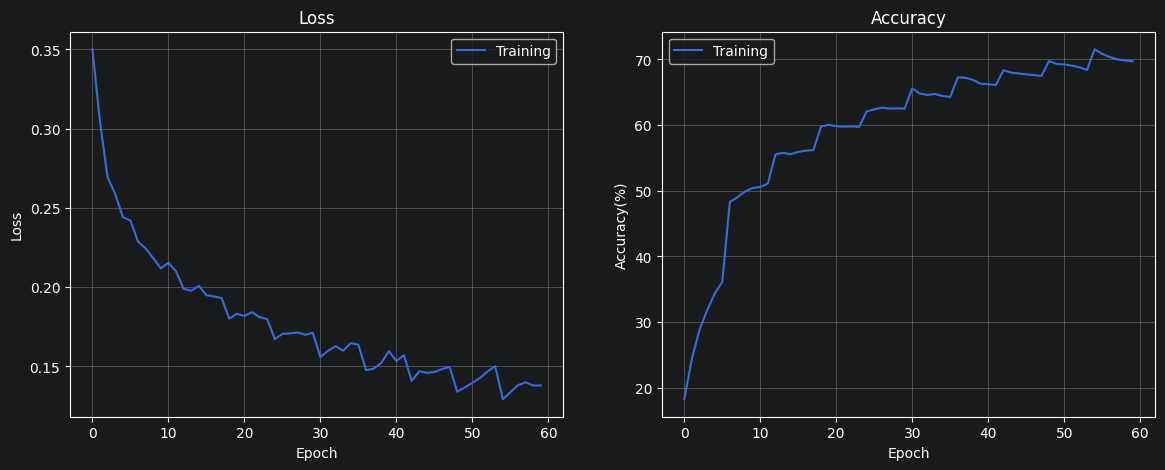

In [117]:
plot_metric(acc_metric,loss_metric)

# 5. Test the network on the test data
We have trained the network for 2 passes over the training dataset. But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network outputs, and checking it against the ground-truth. If the prediction is correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.

dataiter = iter(testloader)

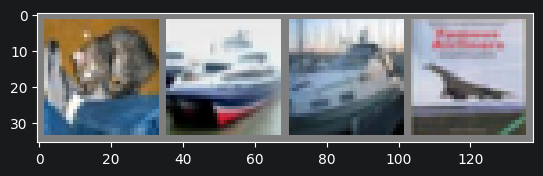

GroundTruth:  cat   ship  ship  plane


In [108]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [109]:
# Après avoir entraîné ton modèle

model.eval()
with torch.no_grad():
    # Prends une image de test
    images, labels = next(iter(testloader))

    # Prédiction
    outputs = model(images[0].unsqueeze(0))

    # Afficher les scores pour les 10 classes
    for i, (classe, score) in enumerate(zip(classes, outputs[0])):
        barre = '█' * int(score * 2)  # Barre visuelle
        print(f"Neurone #{i} ({classe:5s}) : {barre} {score:.2f}")

    # La classe prédite est celle avec le score le plus élevé
    predicted = torch.argmax(outputs, dim=1)
    print(f"\n✅ Prédiction : {classes[predicted]}")
    print(f"   Vérité     : {classes[labels[0]]}")

NameError: name 'model' is not defined